In [35]:
import scipy.special as sc
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
from scipy.optimize import curve_fit
from shapely.geometry import LineString
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from scipy.optimize import minimize

In [80]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 3)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][2]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] and dataframe_1tonne_single.iloc[i,10][2] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    FC = []
    CE = []
    NC = []
    FN = []
    NE = []
    FF = []
    CC = []
    EE = []
    NN = []
    FE = []
    O = []

    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CF' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FC':
            FC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EC':
            CE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NC' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CN':
            NC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FN' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NF':
            FN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EN':
            NE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FF':
            FF.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CC':
            CC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EE':
            EE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NN':
            NN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EF':
            FE.append(i)
        else:
            O.append(i)

    FC = no_NTD_data[no_NTD_data.index.isin(FC)]
    CE = no_NTD_data[no_NTD_data.index.isin(CE)]
    NC = no_NTD_data[no_NTD_data.index.isin(NC)]
    FN = no_NTD_data[no_NTD_data.index.isin(FN)]
    NE = no_NTD_data[no_NTD_data.index.isin(NE)]
    FF = no_NTD_data[no_NTD_data.index.isin(FF)]
    CC = no_NTD_data[no_NTD_data.index.isin(CC)]
    EE = no_NTD_data[no_NTD_data.index.isin(EE)]
    NN = no_NTD_data[no_NTD_data.index.isin(NN)]
    FE = no_NTD_data[no_NTD_data.index.isin(FE)]

    FC =FC.reset_index(drop=True)
    CE =CE.reset_index(drop=True)
    NC =NC.reset_index(drop=True)
    FN =FN.reset_index(drop=True)
    NE =NE.reset_index(drop=True)
    FF =FF.reset_index(drop=True)
    CC =CC.reset_index(drop=True)
    EE =EE.reset_index(drop=True)
    NN =NN.reset_index(drop=True)
    FE =FE.reset_index(drop=True)
    return FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0] + dataframe_1tonne_double.iloc[i,9][1])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [81]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = Topology_Sort(NTD_single)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = Topology_Sort(no_NTD_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2709/2472968775.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2709/1781449791.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_2709/1781449791.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentatio

In [84]:
def NormGuassianExp(x,mu,sigma,b,C, E0, E1):
    return (1-b)*((np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2))+b*(np.exp(-C*x))/((1/C)*(np.exp(-E0*C)-np.exp(-E1*C)))

def NegLogLikelihoodGuassExp(params,data):
    mu,sigma, b, C = params
    E0 = min(data)
    E1 = max(data)
    x = NormGuassianExp(np.asarray(data),mu,sigma,b,C, E0, E1)
    x = x[x>0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLikelihoodGuassExp(data, initial_params):
    result = minimize(NegLogLikelihoodGuassExp, initial_params, args=(data),
                      method='Nelder-Mead', bounds=[(0, None), (0, None), (0,1), (None, None)])
    return result.x

def Chi2(data, arr):
    mu,sigma,b,C, = arr
    E0 = min(data)
    E1 = max(data)
    
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = NormGuassianExp(filtered_bin_centers, mu,sigma,b,C, E0, E1)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Residual_Plot(data, arr):
    mu,sigma,b,C, = arr
    bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]
        
    E0 = min(data)
    E1 = max(data)

    fitted_pdf = NormGuassianExp(filtered_bin_centers, mu,sigma,b,C, E0, E1)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

def Graph(data, arr):
    mu_fit, sigma_fit, b_fit, C_fit = arr
    bin_number = int(max(data) - min(data))
    
    x_values = np.linspace(min(data), max(data), 1000)
    minimum = min(x_values)
    maximum = max(x_values)
    bin_width = (max(data) - min(data))/bin_number
    
    fitted_pdf = NormGuassianExp(x_values, mu_fit, sigma_fit, b_fit, C_fit, minimum, maximum)*(len(data)*bin_width)
    guass = (1-b_fit)*((np.exp(-(x_values-mu_fit)**2/(2*sigma_fit**2)))/np.sqrt(2*np.pi*sigma_fit**2))*len(data)*bin_width
    exp_bckg = b_fit*(np.exp(-C_fit*x_values))/((1/C_fit)*(np.exp(-min(data)*C_fit)-np.exp(-max(data)*C_fit)))*len(data)*bin_width
    
    return x_values, fitted_pdf, guass, exp_bckg

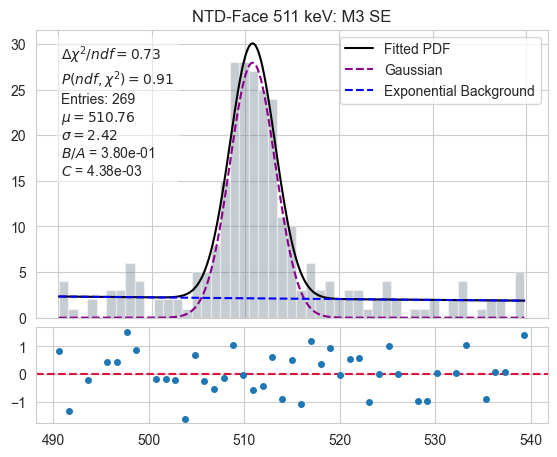

In [47]:
NTD_events = pd.concat([CE_NTD, NC_NTD, NE_NTD, CC_NTD, EE_NTD, NN_NTD])
NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_events)

data = [i for i in NTD_511 if 490 <= i <= 540]
        
mu = 511.185061
sigma = 2.67795154
b = 0.11752725284070993
C = 6.89713150e-03
initial_parms = [mu, sigma, b,C]
parms = MinimizeNegLogLikelihoodGuassExp(data, initial_parms)
# print(f"Fitted parameters: {fitted_params}")

bin_num = int(max(data)-min(data))

x_values, fitted_pdf, guass, exp_bckg = Graph(data, parms)

fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(data, parms)/(bin_num - 4), ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num-4, Chi2(data, parms)), ),
    'Entries: ' + (str(len(data))),
    r'$\mu=%.2f$' % (parms[0], ),
    r'$\sigma=%.2f$' % (parms[1], ),
    r'$B/A$ = ' + str(np.format_float_scientific(parms[2], precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(parms[3], precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fitted PDF', color='black')
ax.plot(x_values, guass, label = 'Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_values, exp_bckg, label = 'Exponential Background', linestyle='--', color='blue')

ax.hist(data, bins = bin_num , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('NTD-Face 511 keV: M3 SE')
ax.legend()

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(data, parms)[0],Residual_Plot(data, parms)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

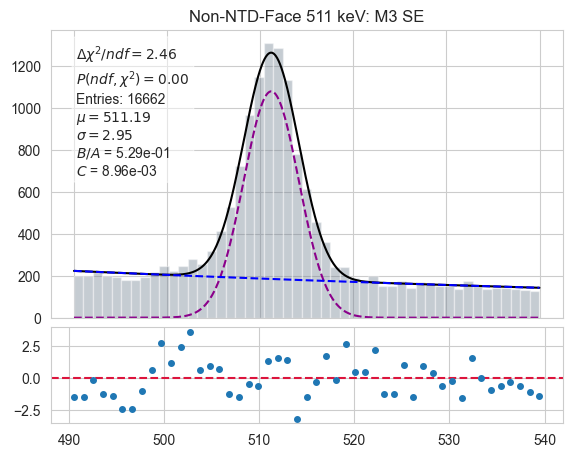

In [48]:
FC = pd.concat([FC, FC_NTD])
FN = pd.concat([FN, FN_NTD])
FF = pd.concat([FF, FF_NTD])
FE = pd.concat([FE, FE_NTD])

NonNTDevents = pd.concat([FC, CE, NC, FN, NE, FF, CC, EE, NN, FE])
NonNTD_2100, NonNTD_511 = PrimarySecondarySplit(NonNTDevents)

dataNonNTD = []

for i in range(len(NonNTD_511)):
    if 490<= NonNTD_511[i] <= 540:
        dataNonNTD.append(NonNTD_511[i])
        
muNonNTD = 511.185061
sigmaNonNTD = 2.67795154
bNonNTD = 0.5
CNonNTD = 6.89713150e-03
initial_parms = [muNonNTD, sigmaNonNTD, bNonNTD,CNonNTD]

parmsNonNTD = MinimizeNegLogLikelihoodGuassExp(dataNonNTD, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
bin_num = int(max(dataNonNTD)-min(dataNonNTD))

x_values, fitted_pdf, guass, exp_bckg = Graph(dataNonNTD, parmsNonNTD)


fig = plt.figure(1)
ax=fig.add_axes((.1,.3,.8,.6))
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(dataNonNTD, parmsNonNTD)/(bin_num - 4), ),
                   r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num-4, Chi2(dataNonNTD, parmsNonNTD)), ),
    'Entries: ' + (str(len(dataNonNTD))),
    r'$\mu=%.2f$' % (parmsNonNTD[0], ),
    r'$\sigma=%.2f$' % (parmsNonNTD[1], ),
    r'$B/A$ = ' + str(np.format_float_scientific(parmsNonNTD[2], precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(parmsNonNTD[3], precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fitted PDF', color='black')
ax.plot(x_values, guass, label = 'Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_values, exp_bckg, label = 'Exponential Background', linestyle='--', color='blue')

ax.hist(dataNonNTD, bins = int(max(dataNonNTD) - min(dataNonNTD)) , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 511 keV: M3 SE')

ax2=fig.add_axes((.1,.08,.8,.2))        
ax2.errorbar(Residual_Plot(dataNonNTD, parmsNonNTD)[0],Residual_Plot(dataNonNTD, parmsNonNTD)[1], fmt='o',markersize=4)
ax2.axhline(0, linestyle='--', color='crimson')

In [85]:
FC_2100, FC_511 = PrimarySecondarySplit(FC)
CE_2100, CE_511 = PrimarySecondarySplit(CE)
NC_2100, NC_511 = PrimarySecondarySplit(NC)
FN_2100, FN_511 = PrimarySecondarySplit(FN)
NE_2100, NE_511 = PrimarySecondarySplit(NE)
FF_2100, FF_511 = PrimarySecondarySplit(FF)
# CC_2100, CC_511 = PrimarySecondarySplit(CC) not enough events to fit anything
EE_2100, EE_511 = PrimarySecondarySplit(EE)
NN_2100, NN_511 = PrimarySecondarySplit(NN)
FE_2100, FE_511 = PrimarySecondarySplit(FE)


CE_2100_NTD, CE_511_NTD = PrimarySecondarySplit(CE_NTD)
NC_2100_NTD, NC_511_NTD = PrimarySecondarySplit(NC_NTD)
NE_2100_NTD, NE_511_NTD = PrimarySecondarySplit(NE_NTD)
CC_2100_NTD, CC_511_NTD = PrimarySecondarySplit(CC_NTD) 
NN_2100_NTD, NN_511_NTD = PrimarySecondarySplit(NN_NTD)

FC_511_cut = [i for i in FC_511 if 490 <= i <= 540]
CE_511_cut = [i for i in CE_511 if 490 <= i <= 540]
NC_511_cut = [i for i in NC_511 if 490 <= i <= 540]
FN_511_cut = [i for i in FN_511 if 490 <= i <= 540]
NE_511_cut = [i for i in NE_511 if 490 <= i <= 540]
FF_511_cut = [i for i in FF_511 if 490 <= i <= 540]
EE_511_cut = [i for i in EE_511 if 490 <= i <= 540]
NN_511_cut = [i for i in NN_511 if 490 <= i <= 540]
FE_511_cut = [i for i in FE_511 if 490 <= i <= 540]

CE_511_cut_NTD = [i for i in CE_511_NTD if 490 <= i <= 540]
NC_511_cut_NTD = [i for i in NC_511_NTD if 490 <= i <= 540]
NE_511_cut_NTD = [i for i in NE_511_NTD if 490 <= i <= 540]
NN_511_cut_NTD = [i for i in NN_511_NTD if 490 <= i <= 540]


FC_initial_511 = [5.11200577e+02, 3.03369145e+00, 0.5, 7.55802068e-03]
CE_initial_511 = [5.11018269e+02, 2.81020118e+00, 0.5,5.87756146e-03]
NC_initial_511 = [5.11182419e+02, 2.78208147e+00, 0.5, 1.27697351e-02]
FN_initial_511 = [5.11850438e+02, 2.92269445e+00, 0.5,6.89676842e-03]
NE_initial_511 = [5.11029528e+02, 2.58916615e+00,  0.5, 1.28240231e-02]
FF_initial_511 = [5.11469486e+02, 2.69210304e+00,  0.5, 6.42837798e-03]
EE_initial_511 = [5.10857992e+02, 3.17146179e+00,  0.5, 8.35769289e-03]
NN_initial_511 = [5.10889791e+02, 2.94974151e+00,  0.5,1.63421618e-02]
FE_initial_511 = [5.11249583e+02, 2.83977420e+00, 0.5, 2.96274049e-03]

FCarr = MinimizeNegLogLikelihoodGuassExp(FC_511_cut, FC_initial_511)
CEarr = MinimizeNegLogLikelihoodGuassExp(CE_511_cut, CE_initial_511)
NCarr = MinimizeNegLogLikelihoodGuassExp(NC_511_cut, NC_initial_511)
FNarr = MinimizeNegLogLikelihoodGuassExp(FN_511_cut, FN_initial_511)
NEarr = MinimizeNegLogLikelihoodGuassExp(NE_511_cut, NE_initial_511)
FFarr = MinimizeNegLogLikelihoodGuassExp(FF_511_cut, FF_initial_511)
EEarr = MinimizeNegLogLikelihoodGuassExp(EE_511_cut, EE_initial_511)
NNarr = MinimizeNegLogLikelihoodGuassExp(NN_511_cut, NN_initial_511)
FEarr = MinimizeNegLogLikelihoodGuassExp(FE_511_cut, FE_initial_511)

CEmu_fit_NTD, CEsigma_fit_NTD, CEb_fit_NTD, CEc_fit_NTD = MinimizeNegLogLikelihoodGuassExp(CE_511_cut_NTD, CE_initial_511)
NCmu_fit_NTD, NCsigma_fit_NTD, NCb_fit_NTD, NCc_fit_NTD = MinimizeNegLogLikelihoodGuassExp(NC_511_cut_NTD, NC_initial_511)
NEmu_fit_NTD, NEsigma_fit_NTD, NEb_fit_NTD, NEc_fit_NTD = MinimizeNegLogLikelihoodGuassExp(NE_511_cut_NTD, NE_initial_511)
NNmu_fit_NTD, NNsigma_fit_NTD, NNb_fit_NTD, NNc_fit_NTD = MinimizeNegLogLikelihoodGuassExp(NN_511_cut_NTD, NN_initial_511)

In [89]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def TopologyPlots(hist_data, initial_parms, topologies, cols, rows):
    bin_num = []
    xvals = []
    chi2s = []
    fitvals = []
    guassvals = []
    expvals = []
    
    for i in range(len(hist_data)):
        x, PDF_fit, guass, exp_bckg = Graph(hist_data[i], initial_parms[i])
        bin_num.append(int(max(hist_data[i])-min(hist_data[i])))
        xvals.append(x)
        fitvals.append(PDF_fit)
        guassvals.append(guass)
        expvals.append(exp_bckg)
        
        chi2s.append(Chi2(hist_data[i], initial_parms[i]))
    
    pvals = []
    
    for j in range(len(chi2s)):
        pvals.append(PValue(bin_num[j],chi2s[j]))
    
    means = []
    sigmas = []
    bs = []
    cs = []
    
    for i in range(len(initial_parms)):
        means.append(initial_parms[i][0])
        sigmas.append(initial_parms[i][1])
        bs.append(initial_parms[i][2])
        cs.append(initial_parms[i][3])
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': hist_data,
        'X-axis': xvals,
        'Fit': fitvals,
        'Guass': guassvals,
        'Exp': expvals,
        'Means': means,
        'Sigmas': sigmas, 
        'Bs': bs,
        'Cs': cs,
        'Chi2': chi2s,
        'p-value': pvals}
    
    df = pd.DataFrame(data)
    
    fig, axs = plt.subplots(cols, rows, figsize=(13,10))
    props = dict(boxstyle='round', facecolor='whitesmoke')

    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join((r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) + '/' + str(df['Bin Num'][i] - 2, ),
            r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
            'Entries: ' + (str(len(df['Histogram Data'][i]))),
            r'$\mu=%.2f$' % (df['Means'][i], ),
            r'$\sigma=%.2f$' % (df['Sigmas'][i], ),
            r'$B/A$ = ' + str(np.format_float_scientific(df['Bs'][i], precision = 2), ),
            r'$C$ = ' + str(np.format_float_scientific(df['Cs'][i], precision = 2), )))
            
            ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=9, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], color='slategray', alpha=0.4)
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='black')
            ax.plot(df['X-axis'][i], df['Guass'][i], label = 'Gaussian', linestyle='--', color='darkmagenta')
            ax.plot(df['X-axis'][i], df['Exp'][i], label = 'Exponential Background', linestyle='--', color='blue')
            ax.set_title(df["Topologies"][i])
            ax.legend(fontsize = 8, loc='upper right')
            ax.set_xticks([])
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.15)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(hist_data[i], initial_parms[i])[0],Residual_Plot(hist_data[i], initial_parms[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()

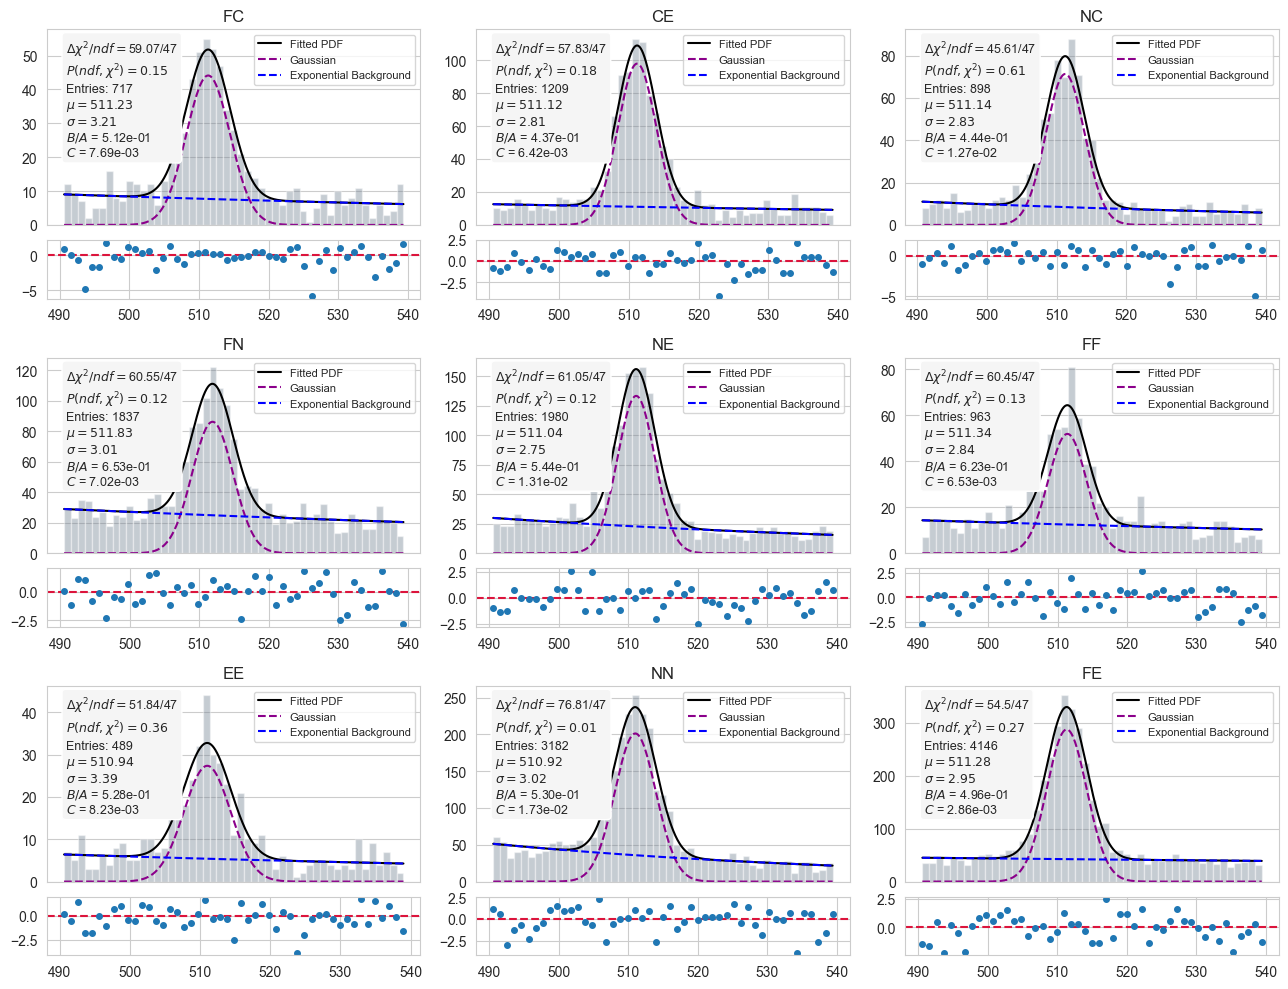

In [90]:
hist_data = [FC_511_cut, CE_511_cut, NC_511_cut, FN_511_cut, NE_511_cut, FF_511_cut, EE_511_cut, NN_511_cut, FE_511_cut]
initial_parms = [FCarr, CEarr, NCarr, FNarr, NEarr, FFarr, EEarr, NNarr, FEarr]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

TopologyPlots(hist_data, initial_parms, topologies,3,3)

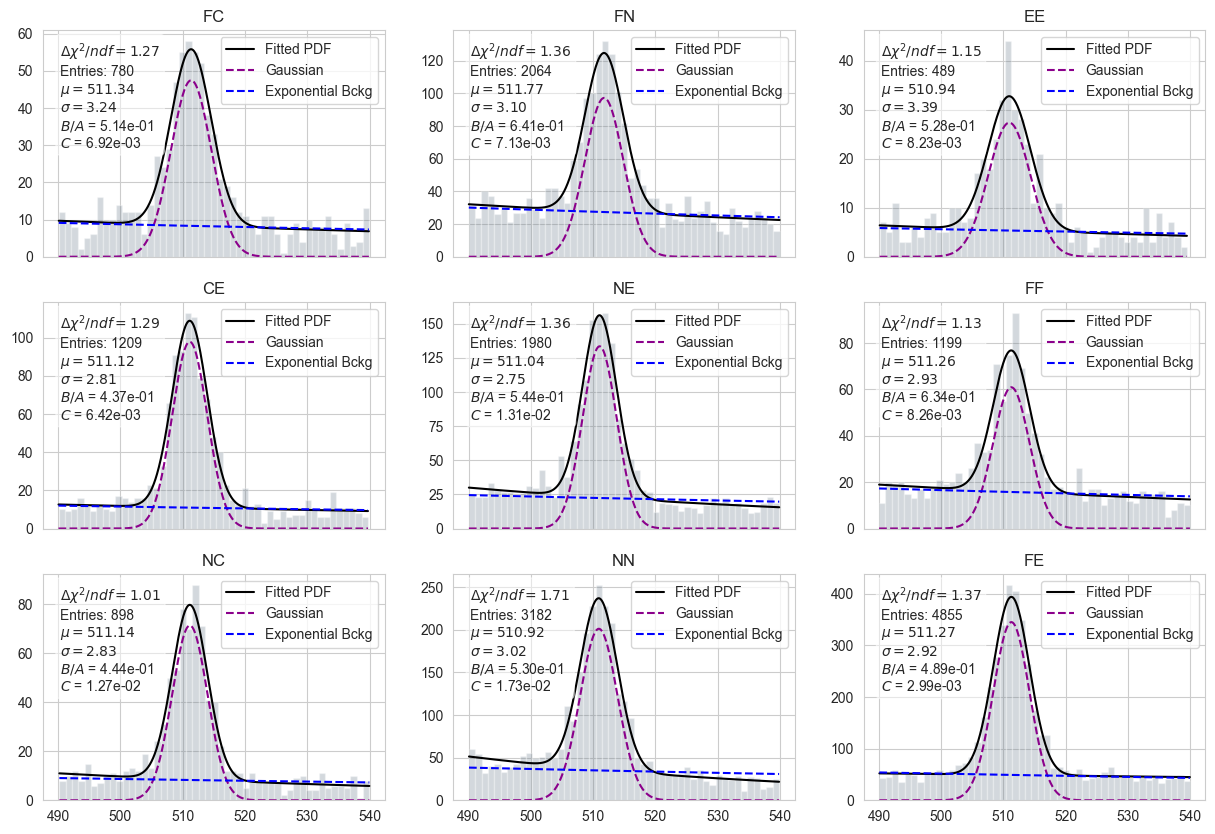

In [33]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(15, 10))
# fig.text(0.04, 0.5, 'Counts', va='center', rotation = 'vertical')
# fig.text(0.5, 0.04, 'Energy (keV)', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# fig.suptitle('Non-NTD Face 511 keV Topology Fits')

textFC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FC_511_cut, FCmu_fit, FCsigma_fit, FCb_fit, FCc_fit)/(int(max(FC_511_cut) - min(FC_511_cut)) - 4), ),
    'Entries: ' + (str(len(FC_511_cut))),
    r'$\mu=%.2f$' % (FCmu_fit, ),
    r'$\sigma=%.2f$' % (FCsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(FCb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(FCc_fit, precision = 2), )))

ax[0,0].plot(FCx, FC_fit, color='black', label='Fitted PDF')
ax[0,0].plot(FCx, FCguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[0,0].plot(FCx, FCexp,label='Exponential Bckg', color='blue', linestyle='--')


ax[0,0].hist(FC_511_cut, bins = int(max(FC_511_cut)-min(FC_511_cut)) , alpha=0.3, color='slategrey')
ax[0,0].text(0.05, 0.95, textFC, transform=ax[0,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('FC')
ax[0,0].legend()
##############
textCE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(CE_511_cut, CEmu_fit, CEsigma_fit, CEb_fit, CEc_fit)/(int(max(CE_511_cut) - min(CE_511_cut)) - 4), ),
    'Entries: ' + (str(len(CE_511_cut))),
    r'$\mu=%.2f$' % (CEmu_fit, ),
    r'$\sigma=%.2f$' % (CEsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(CEb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(CEc_fit, precision = 2), )))

ax[1,0].plot(CEx, CE_fit, color='black', label='Fitted PDF')
ax[1,0].plot(CEx, CEguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[1,0].plot(CEx, CEexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[1,0].hist(CE_511_cut, bins = int(max(CE_511_cut) - min(CE_511_cut)) , alpha=0.3, color='slategrey')
ax[1,0].text(0.05, 0.95, textCE, transform=ax[1,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('CE')
ax[1,0].legend()

#######
textNC = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NC_511_cut, NCmu_fit, NCsigma_fit, NCb_fit, NCc_fit)/(int(max(NC_511_cut) - min(NC_511_cut)) - 4), ),
    'Entries: ' + (str(len(NC_511_cut))),
    r'$\mu=%.2f$' % (NCmu_fit, ),
    r'$\sigma=%.2f$' % (NCsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(NCb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(NCc_fit, precision = 2), )))

ax[2,0].plot(NCx, NC_fit, color='black',label='Fitted PDF')
ax[2,0].plot(NCx, NCguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[2,0].plot(NCx, NCexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[2,0].hist(NC_511_cut, bins = int(max(NC_511_cut) - min(NC_511_cut)) , alpha=0.3, color='slategrey')
ax[2,0].text(0.05, 0.95, textNC, transform=ax[2,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,0].set_title('NC')
ax[2,0].legend()
########
textFN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FN_511_cut, FNmu_fit, FNsigma_fit, FNb_fit, FNc_fit)/(int(max(FN_511_cut) - min(FN_511_cut)) - 4), ),
    'Entries: ' + (str(len(FN_511_cut))),
    r'$\mu=%.2f$' % (FNmu_fit, ),
    r'$\sigma=%.2f$' % (FNsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(FNb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(FNc_fit, precision = 2), )))

ax[0,1].plot(FNx, FN_fit, color='black', label='Fitted PDF')
ax[0,1].plot(FNx, FNguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[0,1].plot(FNx, FNexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[0,1].hist(FN_511_cut, bins = int(max(FN_511_cut) - min(FN_511_cut)), alpha=0.3, color='slategrey')
ax[0,1].text(0.05, 0.95, textFN, transform=ax[0,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('FN')
ax[0,1].legend()
########
textNE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NE_511_cut, NEmu_fit, NEsigma_fit, NEb_fit, NEc_fit)/(int(max(NE_511_cut) - min(NE_511_cut)) - 4), ),
    'Entries: ' + (str(len(NE_511_cut))),
    r'$\mu=%.2f$' % (NEmu_fit, ),
    r'$\sigma=%.2f$' % (NEsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(NEb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(NEc_fit, precision = 2), )))

ax[1,1].plot(NEx, NE_fit, color='black',label='Fitted PDF')
ax[1,1].plot(NEx, NEguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[1,1].plot(NEx, NEexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[1,1].hist(NE_511_cut, bins = int(max(NE_511_cut) - min(NE_511_cut)), alpha=0.3, color='slategrey')
ax[1,1].text(0.05, 0.95, textNE, transform=ax[1,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('NE')
ax[1,1].legend()
########
textFF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FF_511_cut, FFmu_fit, FFsigma_fit, FFb_fit, FFc_fit)/(int(max(FF_511_cut) - min(FF_511_cut)) - 4), ),
    'Entries: ' + (str(len(FF_511_cut))),
    r'$\mu=%.2f$' % (FFmu_fit, ),
    r'$\sigma=%.2f$' % (FFsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(FFb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(FFc_fit, precision = 2), )))

ax[1,2].plot(FFx, FF_fit, color='black', label='Fitted PDF')
ax[1,2].plot(FFx, FFguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[1,2].plot(FFx, FFexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[1,2].hist(FF_511_cut, bins = int(max(FF_511_cut) - min(FF_511_cut)) , alpha=0.3, color='slategrey')
ax[1,2].text(0.05, 0.95, textFF, transform=ax[1,2].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,2].set_title('FF')
ax[1,2].legend()
########
textEE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(EE_511_cut, EEmu_fit, EEsigma_fit, EEb_fit, EEc_fit)/(int(max(EE_511_cut) - min(EE_511_cut)) - 4), ),
    'Entries: ' + (str(len(EE_511_cut))),
    r'$\mu=%.2f$' % (EEmu_fit, ),
    r'$\sigma=%.2f$' % (EEsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(EEb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(EEc_fit, precision = 2), )))

ax[0,2].plot(EEx, EE_fit, color='black', label='Fitted PDF')
ax[0,2].plot(EEx, EEguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[0,2].plot(EEx, EEexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[0,2].hist(EE_511_cut, bins = int(max(EE_511_cut) - min(EE_511_cut)) , alpha=0.3, color='slategrey')
ax[0,2].text(0.05, 0.95, textEE, transform=ax[0,2].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,2].set_title('EE')
ax[0,2].legend()
########
textNN = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NN_511_cut, NNmu_fit, NNsigma_fit, NNb_fit, NNc_fit)/(int(max(NN_511_cut) - min(NN_511_cut)) - 4), ),
    'Entries: ' + (str(len(NN_511_cut))),
    r'$\mu=%.2f$' % (NNmu_fit, ),
    r'$\sigma=%.2f$' % (NNsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(NNb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(NNc_fit, precision = 2), )))

ax[2,1].plot(NNx, NN_fit, color='black', label='Fitted PDF')
ax[2,1].plot(NNx, NNguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[2,1].plot(NNx, NNexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[2,1].hist(NN_511_cut, bins = int(max(NN_511_cut) - min(NN_511_cut)) , alpha=0.3, color='slategrey')
ax[2,1].text(0.05, 0.95, textNN, transform=ax[2,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,1].set_title('NN')
ax[2,1].legend()
########
textFE = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(FE_511_cut, FEmu_fit, FEsigma_fit, FEb_fit, FEc_fit)/(int(max(FE_511_cut) - min(FE_511_cut)) - 4), ),
    'Entries: ' + (str(len(FE_511_cut))),
    r'$\mu=%.2f$' % (FEmu_fit, ),
    r'$\sigma=%.2f$' % (FEsigma_fit, ),
    r'$B/A$ = ' + str(np.format_float_scientific(FEb_fit, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(FEc_fit, precision = 2), )))

ax[2,2].plot(FEx, FE_fit, color='black', label='Fitted PDF')
ax[2,2].plot(FEx, FEguass,label='Gaussian', color='darkmagenta', linestyle='--')
ax[2,2].plot(FEx, FEexp,label='Exponential Bckg', color='blue', linestyle='--')

ax[2,2].hist(FE_511_cut, bins = int(max(FE_511_cut) - min(FE_511_cut)) , alpha=0.3, color='slategrey')
ax[2,2].text(0.05, 0.95, textFE, transform=ax[2,2].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,2].set_title('FE')
ax[2,2].legend()

Text(0.5, 1.0, 'NN')

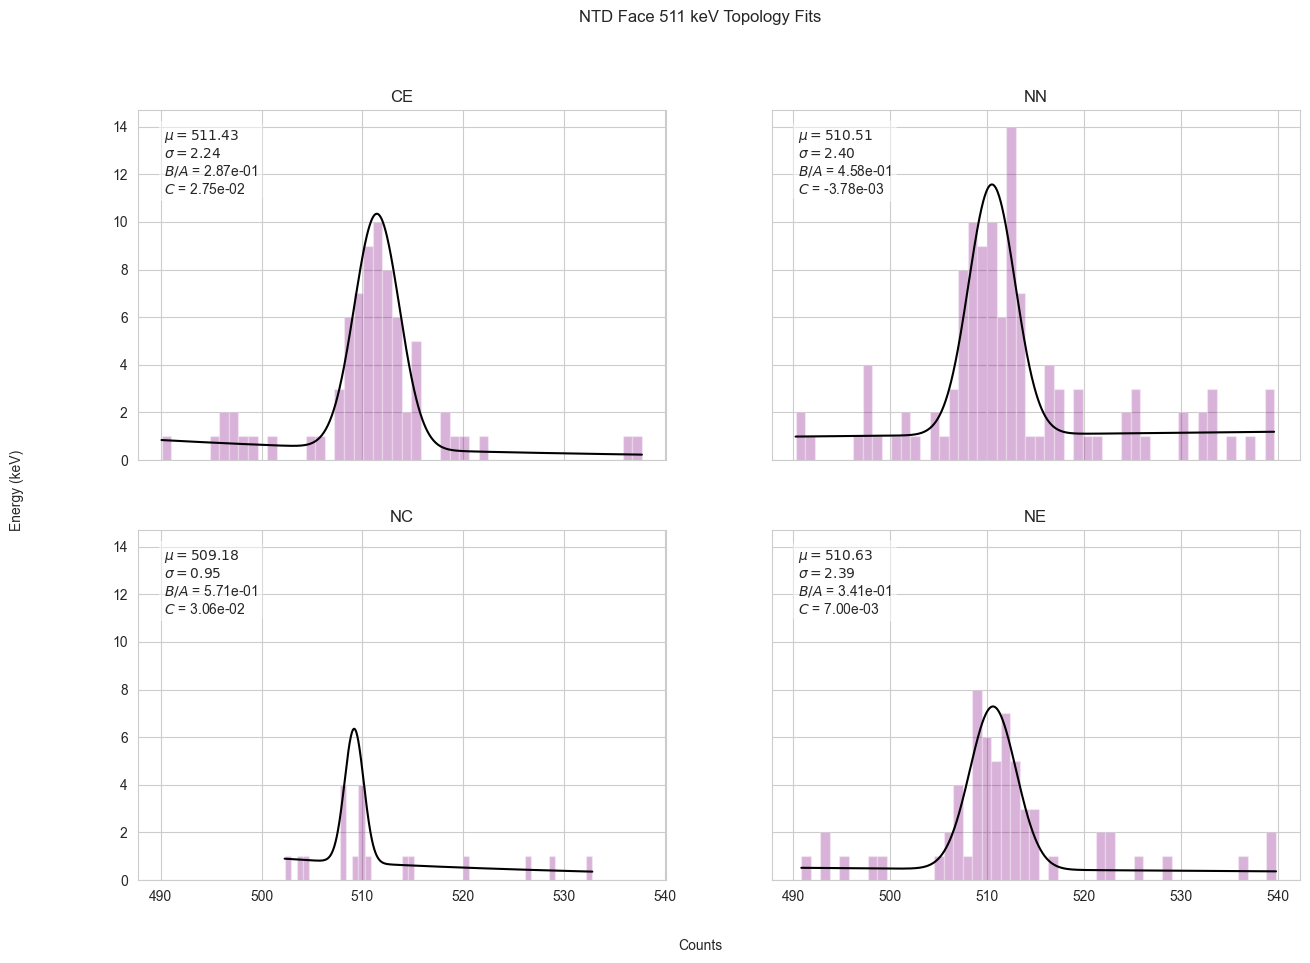

In [294]:
fig, ax = plt.subplots(2,2, sharex='col',sharey=True, figsize=(15, 10))
fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
fig.suptitle('NTD Face 511 keV Topology Fits')


##############
textCE = '\n'.join((
    r'$\mu=%.2f$' % (CEmu_fit_NTD, ),
    r'$\sigma=%.2f$' % (CEsigma_fit_NTD, ),
    r'$B/A$ = ' + str(np.format_float_scientific(CEb_fit_NTD, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(CEc_fit_NTD, precision = 2), )))

ax[0,0].plot(CEx_NTD, CE_fit_NTD, color='black')
ax[0,0].hist(CE_511_cut_NTD, bins = 50 , alpha=0.3, color='purple')
ax[0,0].text(0.05, 0.95, textCE, transform=ax[0,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('CE')
#######
textNC = '\n'.join((
    r'$\mu=%.2f$' % (NCmu_fit_NTD, ),
    r'$\sigma=%.2f$' % (NCsigma_fit_NTD, ),
    r'$B/A$ = ' + str(np.format_float_scientific(NCb_fit_NTD, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(NCc_fit_NTD, precision = 2), )))

ax[1,0].plot(NCx_NTD, NC_fit_NTD, color='black')
ax[1,0].hist(NC_511_cut_NTD, bins = 50 , alpha=0.3, color='purple')
ax[1,0].text(0.05, 0.95, textNC, transform=ax[1,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('NC')
########
textNE = '\n'.join((
    r'$\mu=%.2f$' % (NEmu_fit_NTD, ),
    r'$\sigma=%.2f$' % (NEsigma_fit_NTD, ),
    r'$B/A$ = ' + str(np.format_float_scientific(NEb_fit_NTD, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(NEc_fit_NTD, precision = 2), )))

ax[1,1].plot(NEx_NTD, NE_fit_NTD, color='black')
ax[1,1].hist(NE_511_cut_NTD, bins = 50 , alpha=0.3, color='purple')
ax[1,1].text(0.05, 0.95, textNE, transform=ax[1,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('NE')
########
textNN = '\n'.join((
    r'$\mu=%.2f$' % (NNmu_fit_NTD, ),
    r'$\sigma=%.2f$' % (NNsigma_fit_NTD, ),
    r'$B/A$ = ' + str(np.format_float_scientific(NNb_fit_NTD, precision = 2), ),
r'$C$ = ' + str(np.format_float_scientific(NNc_fit_NTD, precision = 2), )))

ax[0,1].plot(NNx_NTD, NN_fit_NTD, color='black')
ax[0,1].hist(NN_511_cut_NTD, bins = 50 , alpha=0.3, color='purple')
ax[0,1].text(0.05, 0.95, textNN, transform=ax[0,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('NN')

In [252]:
def NegLogLikelihoodGuassExp(params,data):
    mu,sigma, b, C = params
    E0 = min(data)
    E1 = max(data)
    LogL = 0
    for k in data:
        x = NormGuassianExp(k,mu,sigma,b,C, E0, E1)
        # if x > 0:
        LogL += np.log(x)
    return -2*LogL

def Uncertainity(data, mu, sigma,b,c):
    params = [mu, sigma, b, c]
    arr1 = NegLogLikelihoodGuassExp(params, data)
    arr2 = arr1 - min(arr1)
    xaxis = LineString(np.column_stack((arr2,np.linspace(1,1, len(arr2)))))
    if isinstance(mu, float) == False: 
        curve = LineString(np.column_stack((mu, arr2)))
        intersection = xaxis.intersection(curve)
    elif isinstance(mu, float) == True:
        curve = LineString(np.column_stack((sigma, arr2)))
        intersection = curve.intersection(xaxis)
    if str(intersection) == 'LINESTRING Z EMPTY':
        intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.05))[0]
        intersection = mu[intersection_indices]
        # intersection_y = arr2[intersection_indices]
        # intersection = list(zip(intersection_x, intersection_y))
    return intersection, arr2

def Errors(mu_intersections, means):
    upper_errs = []
    lower_errs = []

    for i in range(len(mu_intersections)):
        if mu_intersections[i][0] < mu_intersections[i][1]:
            upper_errs.append(mu_intersections[i][1])
            lower_errs.append(mu_intersections[i][0])
        else:
            upper_errs.append(mu_intersections[i][0])
            lower_errs.append(mu_intersections[i][1])

    top_errs = []
    bot_errs = []
    for i in range(len(upper_errs)):
        top_errs.append(abs(means[i]-upper_errs[i]))
        bot_errs.append(abs(means[i]-lower_errs[i]))

    asymmetric_errormu = np.array(list(zip(bot_errs, top_errs))).T
    return asymmetric_errormu

In [211]:
CEmu_arr = np.linspace(CEmu_fit-5, CEmu_fit+5, 100)
NCmu_arr = np.linspace(NCmu_fit-5, NCmu_fit+5, 100)
FNmu_arr = np.linspace(FNmu_fit-5, FNmu_fit+5, 100)
NEmu_arr = np.linspace(NEmu_fit-5, NEmu_fit+5, 100)
EEmu_arr = np.linspace(EEmu_fit-10, EEmu_fit+10, 10000)
NNmu_arr = np.linspace(NNmu_fit-5, NNmu_fit+5, 100)
FEmu_arr = np.linspace(FEmu_fit-5, FEmu_fit+5, 100)
FCmu_arr = np.linspace(FCmu_fit-10, FCmu_fit+10, 1000)
FFmu_arr = np.linspace(FFmu_fit-5, FFmu_fit+5, 100)

FCintersection_mu, FCerror_mu = Uncertainity(FC_511_cut, FCmu_arr, FCsigma_fit,FCb_fit,FCc_fit) 
CEintersection_mu, CEerror_mu = Uncertainity(CE_511_cut, CEmu_arr, CEsigma_fit,CEb_fit,CEc_fit)
NCintersection_mu, NCerror_mu = Uncertainity(NC_511_cut, NCmu_arr, NCsigma_fit,NCb_fit,NCc_fit)
FNintersection_mu, FNerror_mu = Uncertainity(FN_511_cut, FNmu_arr, FNsigma_fit,FNb_fit,FNc_fit)
NEintersection_mu, NEerror_mu = Uncertainity(NE_511_cut, NEmu_arr, NEsigma_fit,NEb_fit,NEc_fit)
FFintersection_mu, FFerror_mu = Uncertainity(FF_511_cut, FFmu_arr, FFsigma_fit,FFb_fit,FFc_fit) #array
EEintersection_mu, EEerror_mu = Uncertainity(EE_511_cut, EEmu_arr, EEsigma_fit, EEb_fit, EEc_fit)
NNintersection_mu, NNerror_mu = Uncertainity(NN_511_cut, NNmu_arr, NNsigma_fit,NNb_fit,NNc_fit) 
FEintersection_mu, FEerror_mu = Uncertainity(FE_511_cut, FEmu_arr, FEsigma_fit,FEb_fit,FEc_fit) 

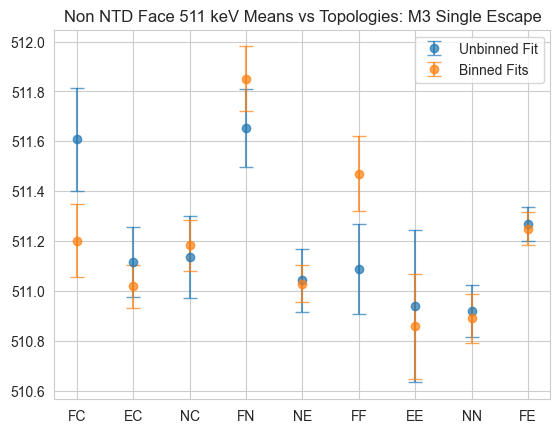

In [213]:
topologies = ['FC', 'EC', 'NC', #'CC', 
              'FN', 'NE', 'FF', 'EE', 'NN', 'FE']
means2 = [511.2005768419917, 511.01826932730324,511.1824192498267,511.85043837544526, 511.02952782373245, 511.4694864836283, 510.8579924898814, 510.88979070962137, 511.24958320026934]
means = [FCmu_fit, CEmu_fit, NCmu_fit, FNmu_fit, NEmu_fit, FFmu_fit, EEmu_fit, NNmu_fit, FEmu_fit]
y_err = [0.14593451578862646, 0.08753871270653875, 0.10309224333169298, 0.12966886001455863, 0.07325109204329525, 0.14970325597908848, 0.21030610891160725, 0.09689675058077198, 0.06689716833742373]

mu_intersections = [[FCintersection_mu.geoms[0].x, FCintersection_mu.geoms[1].x],  [CEintersection_mu.geoms[0].x, CEintersection_mu.geoms[1].x], 
                     [NCintersection_mu.geoms[0].x, NCintersection_mu.geoms[1].x],  
                     [FNintersection_mu.geoms[0].x, FNintersection_mu.geoms[1].x],  [NEintersection_mu.geoms[0].x, NEintersection_mu.geoms[1].x], 
                    [FFintersection_mu.geoms[0].x, FFintersection_mu.geoms[1].x],  [EEintersection_mu.geoms[0].x, EEintersection_mu.geoms[1].x] ,
                   [NNintersection_mu.geoms[0].x, NNintersection_mu.geoms[1].x],  [FEintersection_mu.geoms[0].x, FEintersection_mu.geoms[1].x] ]

asymmetric_errormu = Errors(mu_intersections, means)

plt.errorbar(topologies, means, yerr=asymmetric_errormu, fmt='o', label='Unbinned Fit', alpha=0.7, capsize=5)

plt.errorbar(topologies, means2, yerr=y_err, fmt='o', alpha=0.7, label='Binned Fits', capsize=5)
plt.title('Non NTD Face 511 keV Means vs Topologies: M3 Single Escape')
plt.legend()

In [278]:
FCsigma_arr = np.linspace(FCsigma_fit/2, FCsigma_fit*2, 100)
CEsigma_arr = np.linspace(CEsigma_fit/2, CEsigma_fit*2, 100)
NCsigma_arr = np.linspace(NCsigma_fit/2, NCsigma_fit*2, 100)
FNsigma_arr = np.linspace(FNsigma_fit/2, FNsigma_fit*2, 100)
NEsigma_arr = np.linspace(NEsigma_fit/2, NEsigma_fit*2, 100)
FFsigma_arr = np.linspace(FFsigma_fit/2, FFsigma_fit*2, 100)
EEsigma_arr = np.linspace(EEsigma_fit/2, EEsigma_fit*2, 100)
NNsigma_arr = np.linspace(NNsigma_fit/2, NNsigma_fit*2, 100)
FEsigma_arr = np.linspace(FEsigma_fit/2, FEsigma_fit*2, 100)

FCintersection_sigma, FCerror_sigma = Uncertainity(FC_511_cut, FCmu_fit, FCsigma_arr,FCb_fit,FCc_fit)
CEintersection_sigma, CEerror_sigma = Uncertainity(CE_511_cut, CEmu_fit, CEsigma_arr,CEb_fit,CEc_fit)
NCintersection_sigma, NCerror_sigma = Uncertainity(NC_511_cut, NCmu_fit, NCsigma_arr,NCb_fit,NCc_fit)
FNintersection_sigma, FNerror_sigma = Uncertainity(FN_511_cut, FNmu_fit, FNsigma_arr,FNb_fit,FNc_fit)
NEintersection_sigma, NEerror_sigma = Uncertainity(NE_511_cut, NEmu_fit, NEsigma_arr,NEb_fit,NEc_fit)
FFintersection_sigma, FFerror_sigma = Uncertainity(FF_511_cut, FFmu_fit, FFsigma_arr,FFb_fit,FFc_fit)
EEintersection_sigma, EEerror_sigma = Uncertainity(EE_511_cut, EEmu_fit, EEsigma_arr, EEb_fit, EEc_fit)
NNintersection_sigma, NNerror_sigma = Uncertainity(NN_511_cut, NNmu_fit, NNsigma_arr,NNb_fit,NNc_fit) 
FEintersection_sigma, FEerror_sigma = Uncertainity(FE_511_cut, FEmu_fit, FEsigma_arr,FEb_fit,FEc_fit) 

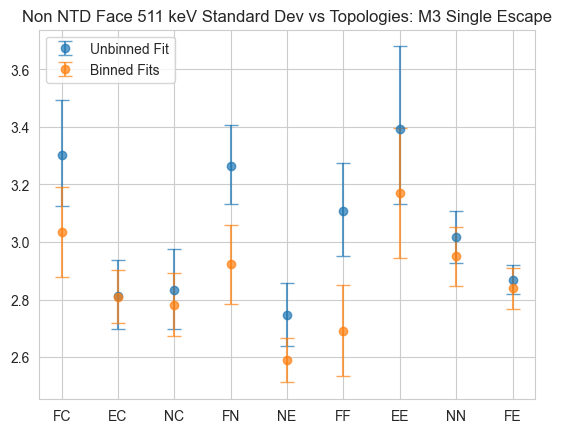

In [279]:
topologies = ['FC', 'EC', 'NC', #'CC', 
              'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

sds = [FCsigma_fit, CEsigma_fit, NCsigma_fit, FNsigma_fit, NEsigma_fit, FFsigma_fit, EEsigma_fit, NNsigma_fit, FEsigma_fit]
sigmas2 = [3.033691450530855, 2.8102011808660556, 2.7820814733223127, 2.922694449016996, 2.589166145859637, 2.6921030414284206, 3.1714617937959297, 2.949741511776945, 2.8397741976573223]
y_err = [0.156072279418157, 0.0931433819760512, 0.1095373078247302, 0.13807647798813233, 0.07748220658520052, 0.1586799843367722, 0.22585384190775468, 0.10347365289261562, 0.07126608709990631]


sigma_intersections = [[FCintersection_sigma.geoms[0].x, FCintersection_sigma.geoms[1].x], [CEintersection_sigma.geoms[0].x, CEintersection_sigma.geoms[1].x], 
                    [NCintersection_sigma.geoms[0].x, NCintersection_sigma.geoms[1].x],  
                    [FNintersection_sigma.geoms[0].x,FNintersection_sigma.geoms[1].x], [NEintersection_sigma.geoms[0].x, NEintersection_sigma.geoms[1].x], 
                    [FFintersection_sigma.geoms[0].x, FFintersection_sigma.geoms[1].x], [EEintersection_sigma.geoms[0].x, EEintersection_sigma.geoms[1].x],
                   [NNintersection_sigma.geoms[0].x, NNintersection_sigma.geoms[1].x], [FEintersection_sigma.geoms[0].x,FEintersection_sigma.geoms[1].x] ]

asymmetric_errorsigma = Errors(sigma_intersections, sds)

plt.errorbar(topologies, sds, yerr=asymmetric_errorsigma, fmt='o', label='Unbinned Fit', alpha=0.7, capsize=5)
plt.errorbar(topologies, sigmas2,yerr=y_err, fmt='o', alpha=0.7, label='Binned Fits', capsize=5)
plt.title('Non NTD Face 511 keV Standard Dev vs Topologies: M3 Single Escape')
plt.legend()

In [214]:
mu_arr = np.linspace(mu_fit-10, mu_fit+10, 10000)
intersection_mu, error_mu = Uncertainity(data, mu_arr, sigma_fit,b_fit,C_fit)
NonNTDmu_arr = np.linspace(NonNTDmu_fit-5, NonNTDmu_fit+5, 1000)
NonNTDintersection_mu, NonNTDerror_mu = Uncertainity(dataNonNTD, NonNTDmu_arr, NonNTDsigma_fit,NonNTDb_fit,NonNTDC_fit)

In [253]:
CEmu_arrNTD = np.linspace(CEmu_fit_NTD-5, CEmu_fit_NTD+5, 100)
NCmu_arrNTD = np.linspace(NCmu_fit_NTD-5, NCmu_fit_NTD+5, 1000)
NEmu_arrNTD = np.linspace(NEmu_fit_NTD-5, NEmu_fit_NTD+5, 1000)
NNmu_arrNTD = np.linspace(NNmu_fit_NTD-5, NNmu_fit_NTD+5, 1000)

CEintersection_muNTD, CEerror_muNTD = Uncertainity(CE_511_cut_NTD, CEmu_arrNTD, CEsigma_fit_NTD,CEb_fit_NTD,CEc_fit_NTD)
NCintersection_muNTD, NCerror_muNTD = Uncertainity(NC_511_cut_NTD, NCmu_arrNTD, NCsigma_fit_NTD,NCb_fit_NTD,NCc_fit_NTD)
NEintersection_muNTD, NEerror_muNTD = Uncertainity(NE_511_cut_NTD, NEmu_arrNTD, NEsigma_fit_NTD,NEb_fit_NTD,NEc_fit_NTD)
NNintersection_muNTD, NNerror_muNTD = Uncertainity(NN_511_cut_NTD, NNmu_arrNTD, NNsigma_fit_NTD,NNb_fit_NTD,NNc_fit_NTD) 

In [260]:
# plt.plot(NNmu_arrNTD, NNerror_muNTD)
# plt.ylim(0,9)
# plt.axvline(NNintersection_muNTD[1])
# plt.axvline(NNintersection_muNTD[2])
# print(NNintersection_muNTD)

Text(0.5, 1.0, 'M3 Single 511 keV Means')

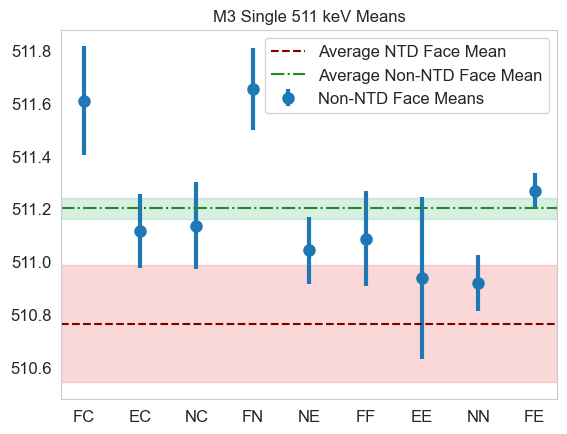

In [263]:
topologiesNTD = ['EC','NC','NE','NN']
NTDmeans = [CEmu_fit_NTD, NCmu_fit_NTD, NEmu_fit_NTD, NNmu_fit_NTD]

topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']

mu_intersections = [[FCintersection_mu.geoms[0].x,FCintersection_mu.geoms[1].x],  [CEintersection_mu.geoms[0].x,CEintersection_mu.geoms[1].x], 
                     [NCintersection_mu.geoms[0].x,NCintersection_mu.geoms[1].x],  
                     [FNintersection_mu.geoms[0].x,FNintersection_mu.geoms[1].x],  
                    [NEintersection_mu.geoms[0].x,NEintersection_mu.geoms[1].x], 
                    [FFintersection_mu.geoms[0].x,FFintersection_mu.geoms[1].x],  
                    [EEintersection_mu.geoms[0].x,EEintersection_mu.geoms[1].x],
                   [NNintersection_mu.geoms[0].x,NNintersection_mu.geoms[1].x],  [FEintersection_mu.geoms[0].x,FEintersection_mu.geoms[1].x]]

nonNTDmeans = [FCmu_fit, CEmu_fit, NCmu_fit, FNmu_fit, NEmu_fit, FFmu_fit, EEmu_fit, NNmu_fit, FEmu_fit]

asymmetric_errormu = Errors(mu_intersections, nonNTDmeans)


mu_intersectionsNTD = [[CEintersection_muNTD[0],CEintersection_muNTD[1]],
                     [NCintersection_muNTD[1],NCintersection_muNTD[2]], 
                    [NEintersection_muNTD[1],NEintersection_muNTD[2]], 
                       [NNintersection_muNTD[1],NNintersection_muNTD[2]]]

ass_errNTD = Errors(mu_intersectionsNTD, NTDmeans)


xNTD = np.arange(len(topologiesNTD))
xNonNTD = np.arange(len(topologiesNonNTD))

plt.errorbar(topologiesNonNTD, nonNTDmeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNonNTD-0.13, nonNTDmeans, yerr=asymmetric_errormu, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
# plt.errorbar(xNTD+0.13, NTDmeans, yerr=ass_errNTD, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

plt.axhspan(intersection_mu.geoms[0].x, intersection_mu.geoms[1].x, color='lightcoral', alpha=0.3)
plt.axhline(mu_fit, color='maroon', linestyle='--', label='Average NTD Face Mean')

plt.axhspan(NonNTDintersection_mu.geoms[0].x, NonNTDintersection_mu.geoms[1].x, color='mediumseagreen', alpha=0.2)
plt.axhline(NonNTDmu_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

plt.legend(fontsize=12)

plt.xticks(xNonNTD, topologiesNonNTD, fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Single 511 keV Means')

In [295]:
for i in range(len(nonNTDmeans)):
    print(str(nonNTDmeans[i]) + '-' + str(asymmetric_errormu[0][i]) + '+' + str(asymmetric_errormu[1][i]))
    
print(mu_fit)
print(mu_fit - intersection_mu.geoms[0].x)
print(mu_fit - intersection_mu.geoms[1].x)

print(NonNTDmu_fit)
print(NonNTDmu_fit - NonNTDintersection_mu.geoms[0].x)
print(NonNTDmu_fit - NonNTDintersection_mu.geoms[1].x)

511.6079800122071-0.20575363470163666+0.2058361720449966
511.11512700982195-0.14054349382536202+0.1405280441115906
511.1361425416524-0.16411783818739423+0.16405166539811944
511.65396538610776-0.1553303921001543+0.15519787036834032
511.0421360611364-0.12496885829921212+0.12474874221584287
511.0866890016593-0.1801520222190902+0.17982000550853172
510.93951000291645-0.30664558395704944+0.3059853797369101
510.918943308758-0.10444796968533865+0.10447894055869256
511.2674795980812-0.06876145110783227+0.0687567849325319
510.7649760854132
0.22221936591091662
-0.22223533538800666
511.188031880636
0.026576268869632713
-0.05385082023542509


In [280]:
NonNTDsigma_arr = np.linspace(NonNTDsigma_fit/2, NonNTDsigma_fit*2, 100)
NonNTDintersection_sigma, NonNTDerror_sigma = Uncertainity(dataNonNTD, NonNTDmu_fit, NonNTDsigma_arr,NonNTDb_fit,NonNTDC_fit)
sigma_arr = np.linspace(sigma_fit/2, sigma_fit*2, 100)
intersection_sigma, error_sigma = Uncertainity(data, mu_fit, sigma_arr,b_fit,C_fit)

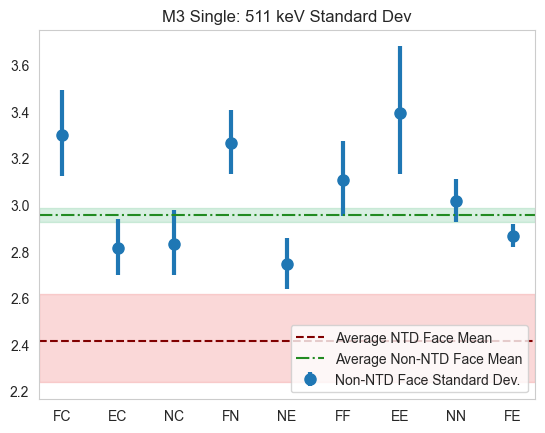

In [283]:
ax = plt.subplot()

topologies = ['FC', 'EC', 'NC', #'CC', 
              'FN', 'NE', 'FF', 'EE', 'NN', 'FE']
sds = [FCsigma_fit, CEsigma_fit, NCsigma_fit, FNsigma_fit, NEsigma_fit, FFsigma_fit, EEsigma_fit, NNsigma_fit, FEsigma_fit]
ax.errorbar(topologies, sds, yerr=asymmetric_errorsigma, ms = 8, elinewidth=3, fmt='o', label='Non-NTD Face Standard Dev.')
ax.axhspan(intersection_sigma.geoms[0].x, intersection_sigma.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(sigma_fit, color='maroon', linestyle='--', label='Average NTD Face Mean')

ax.axhspan(NonNTDintersection_sigma.geoms[0].x, NonNTDintersection_sigma.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(NonNTDsigma_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

ax.legend(loc='lower right')
plt.title('M3 Single: 511 keV Standard Dev')
ax.grid(False)

In [296]:
for i in range(len(sds)):
    print(str(sds[i]) + '-' + str(asymmetric_errorsigma[0][i]) + '+' + str(asymmetric_errorsigma[1][i]))
    
print(sigma_fit)
print(sigma_fit - intersection_sigma.geoms[0].x)
print(sigma_fit - intersection_sigma.geoms[1].x)

print(NonNTDsigma_fit)
print(NonNTDsigma_fit - NonNTDintersection_sigma.geoms[0].x)
print(NonNTDsigma_fit - NonNTDintersection_sigma.geoms[1].x)

3.3014770609130433-0.17726840922523257+0.19199626708754636
2.813780817025423-0.11579242665531586+0.12403471079491757
2.833427952221429-0.1351603392848455+0.14357705111905572
3.264960118124419-0.13283540049770792+0.14013963631240012
2.745951470931077-0.10664204348460382+0.1121595256176322
3.107476702666438-0.1558356543182482+0.16542538834819132
3.3944707879677196-0.2613055036052958+0.28517373698696735
3.0156700146978968-0.09009495811805435+0.09364652677101537
2.867618682957231-0.05004799176331387+0.051219875219320254
2.4171241059906854
-0.19802465617533116
0.179920916861537
2.95352811264956
-0.03157194385690687
0.026453223510311208


In [6]:
def AddSigmaToInt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} \-$\sigma$" if plt.rcParams["text.usetex"] else f"{s} -$\sigma$"

def AddSigmaToInt(x):
    sqrtx = np.sqrt(x)
    s = f"{sqrtx:.1f}"
    if s.endswith("0"):
        s = f"{sqrtx:.0f}"
    return f"{s}-$\\sigma$"

def LikelihoodGraphs2D(data, mu_fit, sigma_fit, b_fit, c_fit, title, bplot=False):
    mus = np.linspace(mu_fit+5,mu_fit-5,100)
    sigmas = np.linspace(sigma_fit/2, sigma_fit*2,100)
    bs = np.linspace(b_fit/2, b_fit*2, 100)
    cs = np.linspace(c_fit/2, c_fit*2,100)
    
    if bplot:
        
        muVals_meshgrid, sigmaVals_meshgrid = np.meshgrid(mus, sigmas)
        ZmuVsigma = NegLogLikelihoodGuassExp([muVals_meshgrid, sigmaVals_meshgrid, b_fit, c_fit], data)
        ZmuVsigma_vals = ZmuVsigma - np.min(ZmuVsigma)
        
        fig, ax = plt.subplots(2,3, figsize=(15, 10))
        fig.suptitle(title, y=0.9)
        fig.tight_layout(pad=5.0)
        contour1 = ax[0,0].contourf(muVals_meshgrid, sigmaVals_meshgrid,ZmuVsigma_vals , 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        CS = ax[0,0].contour(muVals_meshgrid, sigmaVals_meshgrid, ZmuVsigma_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,0].clabel(CS, CS.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,0].set_xlabel('$\mu$')
        ax[0,0].set_ylabel('$\sigma$')
        cbar1 = fig.colorbar(contour1, ax=ax[0,0])

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,0].plot(mu_fit, sigma_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,0].set_title('Sigma vs Mu')
        # ax[0,0].set_xlim(2103,2105)
        # ax[0,0].set_ylim(2,4)
        
    ######################
    
        muVals_meshgrid, bVals_meshgrid = np.meshgrid(mus, bs)
        ZmuVb = NegLogLikelihoodGuassExp([muVals_meshgrid, sigma_fit, bVals_meshgrid, c_fit], data)
        ZmuVb_vals = ZmuVb - np.min(ZmuVb)
        
        contour2 = ax[1,0].contourf(muVals_meshgrid, bVals_meshgrid, ZmuVb_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar2 = fig.colorbar(contour2, ax=ax[1,0])
        CS2 = ax[1,0].contour(muVals_meshgrid, bVals_meshgrid, ZmuVb_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,0].clabel(CS2, CS2.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        plt.grid();
        ax[1,0].set_xlabel('$\mu$')
        ax[1,0].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,0].plot(mu_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,0].set_title('b vs Mu')
    ##################
    
        muVals_meshgrid, cVals_meshgrid = np.meshgrid(mus, cs)
        ZmuVc = NegLogLikelihoodGuassExp([muVals_meshgrid, sigma_fit, b_fit, cVals_meshgrid], data)
        ZmuVc_vals = ZmuVc - np.min(ZmuVc)
    
        contour3 = ax[1,1].contourf(muVals_meshgrid, cVals_meshgrid, ZmuVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar3 = fig.colorbar(contour3, ax=ax[1,1])
        CS3 = ax[1,1].contour(muVals_meshgrid, cVals_meshgrid, ZmuVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,1].clabel(CS3, CS3.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[1,1].set_xlabel('$\mu$')
        ax[1,1].set_ylabel('$c = C/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,1].plot(mu_fit, c_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,1].set_title('c vs mu')
    ##############
    
        sigmaVals_meshgrid, bVals_meshgrid = np.meshgrid(sigmas, bs)
        ZsigmaVb = NegLogLikelihoodGuassExp([mu_fit, sigmaVals_meshgrid, bVals_meshgrid, c_fit], data)
        ZsigmaVb_vals = ZsigmaVb - np.min(ZsigmaVb)
        
        contour4 = ax[0,1].contourf(sigmaVals_meshgrid, bVals_meshgrid, ZsigmaVb_vals , 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar4 = fig.colorbar(contour4, ax=ax[0,1])
        CS4 = ax[0,1].contour(sigmaVals_meshgrid, bVals_meshgrid, ZsigmaVb_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,1].clabel(CS4, CS4.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,1].set_xlabel('$\sigma$')
        ax[0,1].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,1].plot(sigma_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,1].set_title('b vs Sigma')
    ##############
        sigmaVals_meshgrid, cVals_meshgrid = np.meshgrid(sigmas, cs)
        ZsigmaVc = NegLogLikelihoodGuassExp([mu_fit, sigmaVals_meshgrid, b_fit, cVals_meshgrid], data)
        ZsigmaVc_vals = ZsigmaVc - np.min(ZsigmaVc)
    
        contour5 = ax[0,2].contourf(sigmaVals_meshgrid, cVals_meshgrid, ZsigmaVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar5 = fig.colorbar(contour5, ax=ax[0,2])
        CS5 = ax[0,2].contour(sigmaVals_meshgrid, cVals_meshgrid, ZsigmaVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,2].clabel(CS5, CS5.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,2].set_xlabel('$\sigma$')
        ax[0,2].set_ylabel('$c = C/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,2].plot(sigma_fit, c_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,2].set_title('c vs Sigma')
    ##############
        cVals_meshgrid, bVals_meshgrid = np.meshgrid(cs, bs)
        ZbVc = NegLogLikelihoodGuassExp([mu_fit, sigma_fit, bVals_meshgrid, cVals_meshgrid], data)
        ZbVc_vals = ZbVc - np.min(ZbVc)
    
        contour6 = ax[1,2].contourf(cVals_meshgrid, bVals_meshgrid,ZbVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar6 = fig.colorbar(contour6, ax=ax[1,2])
        CS6 = ax[1,2].contour(cVals_meshgrid, bVals_meshgrid, ZbVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,2].clabel(CS6, CS6.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[1,2].set_xlabel('$c = C/A$')
        ax[1,2].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,2].plot(c_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,2].set_title('c vs b')
        
        plt.show()